In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import joblib
from pathlib import Path
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, RocCurveDisplay)
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings("ignore")

df_raw = pd.read_csv("../data/raw/athlete_sessions.csv")
SIGNALS = ["heart_rate","hrv","reaction_time_ms","decision_accuracy",
           "pupil_diameter","blink_rate","saccade_velocity",
           "cortisol_proxy","focus_score","movement_efficiency"]

agg = {s: ["mean","std"] for s in SIGNALS}
agg["state"] = "first"
agg["state_label"] = "first"

df = df_raw.groupby("session_id").agg(agg)
df.columns = ["_".join(c) for c in df.columns]
df = df.rename(columns={"state_first":"state","state_label_first":"state_label"})
df = df.reset_index()

FEAT_COLS = [c for c in df.columns if c not in
             ["session_id","state","state_label"]]
X = df[FEAT_COLS].values
y = df["state"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Train: {X_train.shape} | Test: {X_test.shape}")

Train: (1680, 20) | Test: (420, 20)


In [9]:
rf = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", RandomForestClassifier(
        n_estimators=300, max_depth=15,
        random_state=42, n_jobs=-1))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(rf, X_train, y_train, cv=cv, scoring="accuracy")
print(f"CV Accuracy: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")

rf.fit(X_train, y_train)
y_pred  = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)
auc     = roc_auc_score(y_test, y_proba, multi_class="ovr")

print(f"\nTest Accuracy: {(y_pred==y_test).mean():.3f}")
print(f"ROC-AUC (OVR): {auc:.3f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred,
      target_names=["fatigued","normal","zone"]))

Path("../models").mkdir(exist_ok=True)
joblib.dump(rf, "../models/zone_classifier.pkl")
print("Model saved to models/zone_classifier.pkl")

CV Accuracy: 1.000 ± 0.000

Test Accuracy: 1.000
ROC-AUC (OVR): 1.000

Classification Report:
              precision    recall  f1-score   support

    fatigued       1.00      1.00      1.00       140
      normal       1.00      1.00      1.00       140
        zone       1.00      1.00      1.00       140

    accuracy                           1.00       420
   macro avg       1.00      1.00      1.00       420
weighted avg       1.00      1.00      1.00       420

Model saved to models/zone_classifier.pkl


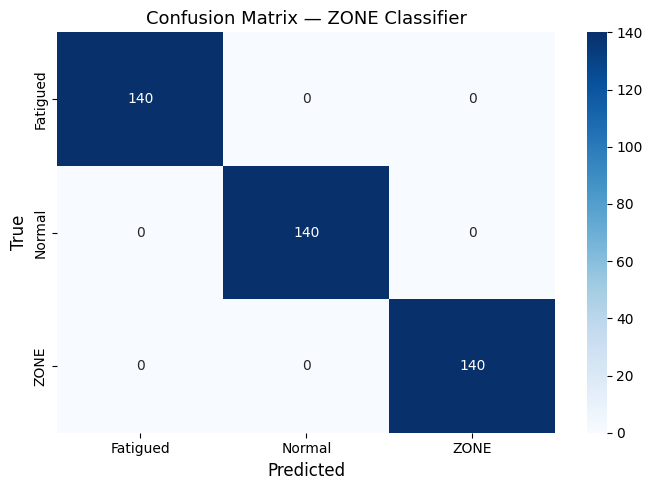

In [10]:
cm = confusion_matrix(y_test, y_pred)
labels_str = ["Fatigued","Normal","ZONE"]

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels_str, yticklabels=labels_str, ax=ax)
ax.set_xlabel("Predicted", fontsize=12)
ax.set_ylabel("True", fontsize=12)
ax.set_title("Confusion Matrix — ZONE Classifier", fontsize=13)
plt.tight_layout()
plt.savefig("../data/confusion_matrix.png", bbox_inches="tight")
plt.show()

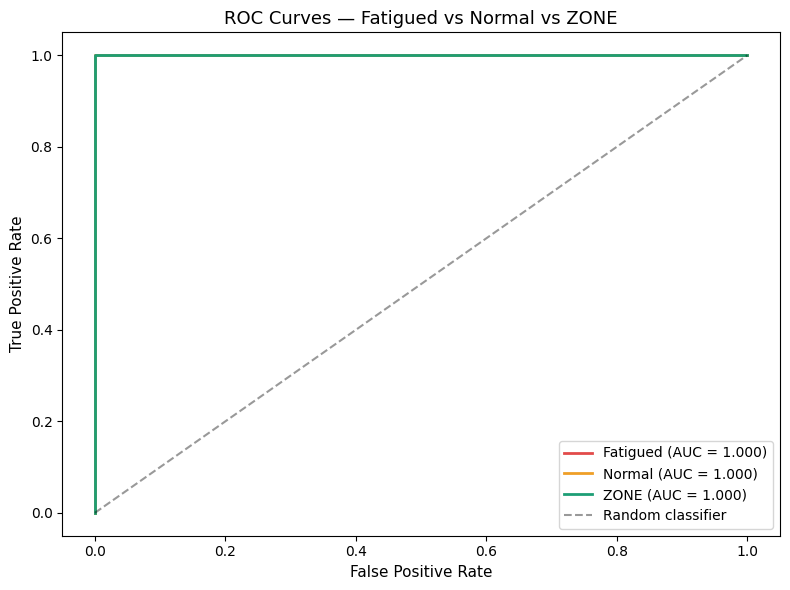

In [11]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc as auc_score

y_test_bin = label_binarize(y_test, classes=[0,1,2])
state_names = ["Fatigued","Normal","ZONE"]
colors_roc  = ["#E24B4A","#EF9F27","#1D9E75"]

fig, ax = plt.subplots(figsize=(8, 6))
for i, (name, color) in enumerate(zip(state_names, colors_roc)):
    fpr, tpr, _ = roc_curve(y_test_bin[:,i], y_proba[:,i])
    roc_auc = auc_score(fpr, tpr)
    ax.plot(fpr, tpr, color=color, linewidth=2,
            label=f"{name} (AUC = {roc_auc:.3f})")

ax.plot([0,1],[0,1],"k--", alpha=0.4, label="Random classifier")
ax.set_xlabel("False Positive Rate", fontsize=11)
ax.set_ylabel("True Positive Rate", fontsize=11)
ax.set_title("ROC Curves — Fatigued vs Normal vs ZONE", fontsize=13)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig("../data/roc_curves.png", bbox_inches="tight")
plt.show()

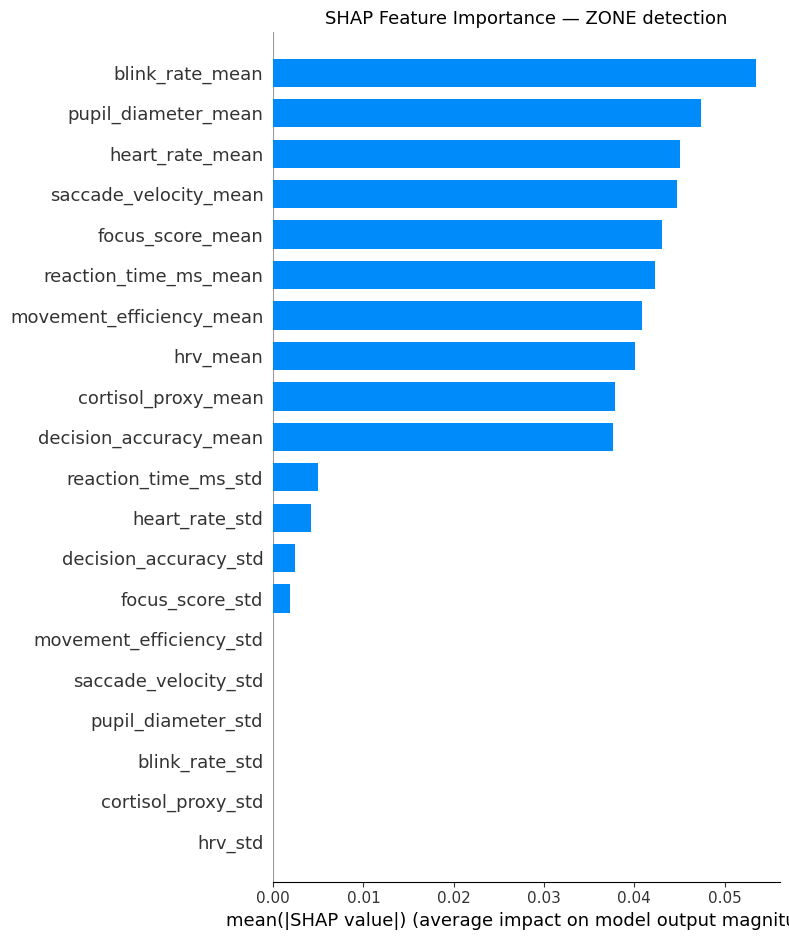

In [13]:
X_test_sc = rf.named_steps["scaler"].transform(X_test)
explainer  = shap.TreeExplainer(rf.named_steps["clf"])
shap_vals  = explainer.shap_values(X_test_sc)

fig, ax = plt.subplots(figsize=(10, 7))
shap.summary_plot(shap_vals[:,:,2] if isinstance(shap_vals, np.ndarray) else shap_vals[2], X_test_sc,
                  feature_names=FEAT_COLS,
                  plot_type="bar",
                  class_names=["Fatigued","Normal","ZONE"],
                  show=False)
plt.title("SHAP Feature Importance — ZONE detection", fontsize=13)
plt.tight_layout()
plt.savefig("../data/shap_importance.png", bbox_inches="tight")
plt.show()